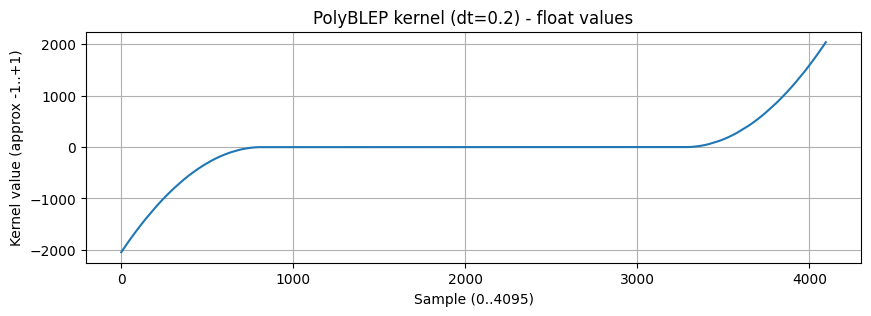

In [4]:
# Generating PolyBLEP kernel, 4096 samples,
# and producing uint16 wavetable versions for 10bit/11bit/12bit.
# Also plot the float kernel and print C-style arrays for each bit depth.
import numpy as np
import matplotlib.pyplot as plt

def polyblep_kernel(t, dt):
    # t can be numpy array in [0,1)
    t = np.asarray(t)
    out = np.zeros_like(t, dtype=float)
    # left side: 0 <= t < dt
    mask1 = (t >= 0.0) & (t < dt)
    if np.any(mask1):
        s = t[mask1] / dt  # s in [0,1)
        out[mask1] = s + s - s*s - 1.0  # t+t - t^2 - 1 
    # middle: dt <= t <= 1-dt -> 0 (already zero)
    # right side: 1-dt < t < 1
    mask2 = (t > 1.0 - dt) & (t < 1.0 + 1e-12)
    if np.any(mask2):
        s = (t[mask2] - 1.0) / dt  # s in (-1,0]
        out[mask2] = s*s + s + s + 1.0  # t*t + t+t +1  (with s variable)
    return out

# parameters
size = 4096
dt = 0.2
t = np.linspace(0.0, 1.0, size, endpoint=False)  # phase samples across [0,1)

kernel_float = polyblep_kernel(t, dt=dt)  # float in approximately [-1.0, +1.0]

# normalize: map [-1..+1] -> [0..1] then scale to integer
def to_int_table(kernel, bits):
    assert bits in (10,11,12)
    max_val = ((1 << bits) >> 1) - 1
    table = np.round(kernel * max_val).astype(np.int16)
    return table

tbl10 = to_int_table(kernel_float, 10)
tbl11 = to_int_table(kernel_float, 11)
tbl12 = to_int_table(kernel_float, 12)

# Plot the float kernel
plt.figure(figsize=(10,3))
plt.plot(tbl12)
plt.title(f"PolyBLEP kernel (dt={dt}) - float values")
plt.xlabel("Sample (0..4095)")
plt.ylabel("Kernel value (approx -1..+1)")
plt.grid(True)
plt.show()

# Also save C-style header file
def save_c_header(path, name, table):
    with open(path, "w") as f:
        f.write(f'#pragma once\n')
        f.write(f'#include <Arduino.h>\n')
        f.write(f"// PolyBLEP kernel table ({name}), {len(table)} samples\n")
        f.write(f"const int16_t {name}[{len(table)}] = {{\n")
        for i in range(0, len(table)):
            if i % 16 == 0:
                f.write("    ")
            f.write(str(int(table[i])))
            if i != len(table)-1:
                f.write(", ")
            if (i+1) % 16 == 0:
                f.write("\n")
        f.write("\n};\n")

save_c_header("polyblep_10bit_4096.h", "polyblep_10bit", tbl10)
save_c_header("polyblep_11bit_4096.h", "polyblep_11bit", tbl11)
save_c_header("polyblep_12bit_4096.h", "polyblep_12bit", tbl12)

